<a href="https://colab.research.google.com/github/juliosdutra/modelagem-processos-dados/blob/main/exercicios/Housing_aula.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd
import seaborn as sns

In [2]:
# URL do arquivo hospedado no GitHub
url = "https://raw.githubusercontent.com/juliosdutra/modelagem-processos-dados/refs/heads/main/dados/housing.data.txt"

# Nomes originais das 13 variáveis + variável alvo (MEDV)
colunas = [
    "CRIM",    # Taxa de criminalidade per capita
    "ZN",      # Proporção de terrenos residenciais zoneados para lotes acima de 25.000 pés²
    "INDUS",   # Proporção de acres comerciais não varejistas por cidade
    "CHAS",    # Variável dummy do rio Charles (=1 se o trecho limita o rio)
    "NOX",     # Concentração de óxidos nítricos (ppm)
    "RM",      # Número médio de cômodos por residência
    "AGE",     # Proporção de unidades ocupadas pelos proprietários construídas antes de 1940
    "DIS",     # Distância ponderada até cinco centros de emprego em Boston
    "RAD",     # Índice de acessibilidade a rodovias radiais
    "TAX",     # Taxa de imposto sobre propriedade por US$10.000
    "PTRATIO", # Razão aluno/professor por cidade
    "B",       # 1000(Bk - 0.63)² onde Bk é a proporção de negros por cidade
    "LSTAT",   # % da população de menor status socioeconômico
    "MEDV"     # Valor médio das casas ocupadas pelos proprietários (em $1000)
]

# Leitura do arquivo
df = pd.read_csv(url, sep=r"\s+", names=colunas)

# Visualizar as primeiras linhas
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [3]:
df.isna().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CRIM,506.0,3.613524,8.601545,0.00632,0.082045,0.25651,3.677083,88.9762
ZN,506.0,11.363636,23.322453,0.00000,0.000000,0.00000,12.500000,100.0000
INDUS,506.0,11.136779,6.860353,0.46000,5.190000,9.69000,18.100000,27.7400
CHAS,506.0,0.069170,0.253994,0.00000,0.000000,0.00000,0.000000,1.0000
NOX,506.0,0.554695,0.115878,0.38500,0.449000,0.53800,0.624000,0.8710
RM,506.0,6.284634,0.702617,3.56100,5.885500,6.20850,6.623500,8.7800
AGE,506.0,68.574901,28.148861,2.90000,45.025000,77.50000,94.075000,100.0000
DIS,506.0,3.795043,2.105710,1.12960,2.100175,3.20745,5.188425,12.1265
RAD,506.0,9.549407,8.707259,1.00000,4.000000,5.00000,24.000000,24.0000
TAX,506.0,408.237154,168.537116,187.00000,279.000000,330.00000,666.000000,711.0000


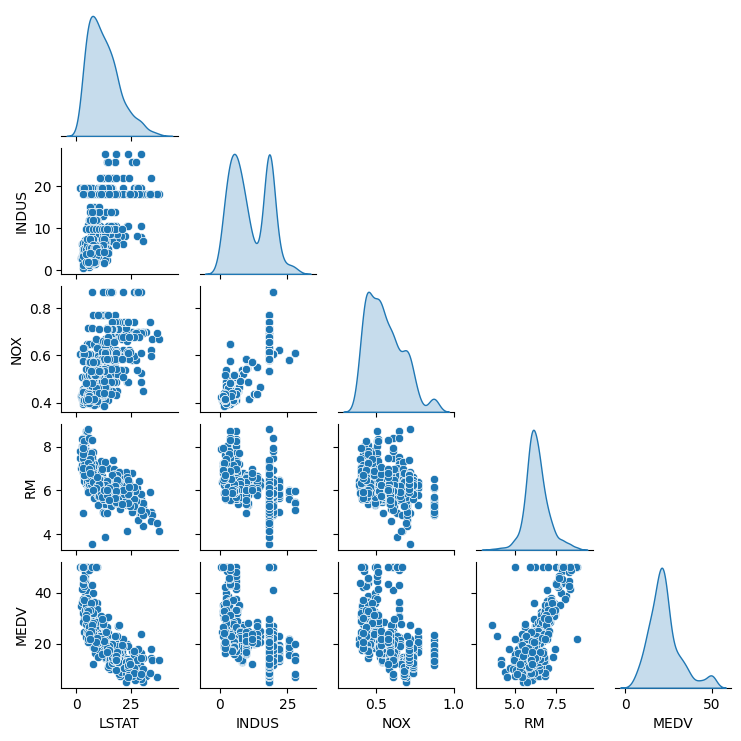

In [5]:
cols = ['LSTAT', 'INDUS', 'NOX', 'RM', 'MEDV']
sns.pairplot(df[cols], height=1.5,
             corner=True, diag_kind='kde',) # hist
plt.show()

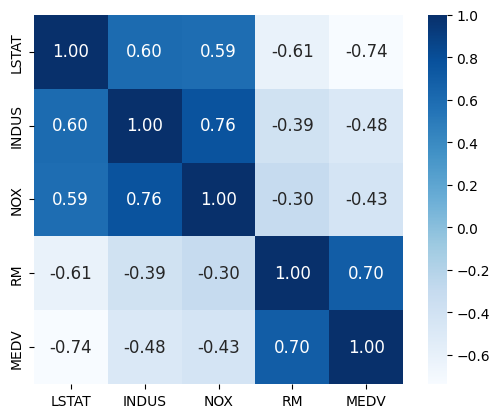

In [6]:
cm = np.corrcoef(df[cols].values.T)

hm = sns.heatmap(cm,
            cbar=True,
            cmap='Blues',
            annot=True,
            square=True,
            fmt='.2f',
            annot_kws={'size': 12},
            yticklabels=cols,
            xticklabels=cols)

In [7]:
df.corrwith(df['MEDV']).abs().sort_values(ascending=False)

,0
MEDV,1.000000
LSTAT,0.737663
RM,0.695360
PTRATIO,0.507787
INDUS,0.483725
TAX,0.468536
NOX,0.427321
CRIM,0.388305
RAD,0.381626
AGE,0.376955


# Implementar um modelo de regressão linear

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [9]:
dados = df[['RM','MEDV']].values

X = dados[:,0:1]
y = dados[:,1]

# Solução fechada (analítica)

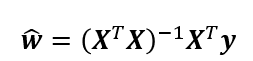

In [10]:
vec_ones = np.ones(X.shape[0]).reshape(-1,1)
Xaug = np.hstack([vec_ones, X])
w = np.linalg.inv(Xaug.T @ Xaug) @ (Xaug.T @ y)

print(f'Intercepto: {w[0]:.3f}')
print(f'Inclinação: {w[1]:.3f}')

ypred = Xaug @ w
mse = mean_squared_error(y, ypred)
r2 = r2_score(y, ypred)

print(f'RMSE: {mse**0.5:.3f}')
print(f'R2: {r2:.3f}')

Intercepto: -34.671
Inclinação: 9.102
RMSE: 6.603
R2: 0.484


In [11]:
lr = LinearRegression()
lr.fit(X, y)

print(f'Intercepto: {lr.intercept_:.3f}')
print(f'Inclinação: {lr.coef_[0]:.3f}')
print(f'R2: {lr.score(X, y):.3f}')

Intercepto: -34.671
Inclinação: 9.102
R2: 0.484


In [12]:
num_comodos = [5.0]
price = lr.predict([num_comodos])
print(f'Previsão de preço ($1000): {price[0]:.2f}')

Previsão de preço ($1000): 10.84


# Usando mais variáveis explicativas

In [13]:
dados = df[['RM','LSTAT','MEDV']].values

X = dados[:,0:2]
y = dados[:,2]

lr2 = LinearRegression()
lr2.fit(X, y)

print(f'Intercepto: {lr2.intercept_:.3f}')
print(f'Coeficientes: {lr2.coef_[0]:.3f}, {lr2.coef_[1]:.3f}')
print(f'R2: {lr2.score(X, y):.3f}')

Intercepto: -1.358
Coeficientes: 5.095, -0.642
R2: 0.639


In [14]:
from os import lstat
import plotly.graph_objects as go

# Gerar uma malha de valores para o plano LSTAT x RM
rm_range = np.linspace(X[:, 0].min(), X[:, 0].max(), 50)
lstat_range = np.linspace(X[:, 1].min(), X[:, 1].max(), 50)
rm_mesh, lstat_mesh = np.meshgrid(rm_range, lstat_range)

# Predição para o plano
MEDV_pred = (lr2.intercept_
             + lr2.coef_[0]*rm_mesh
             + lr2.coef_[1]*lstat_mesh)

# Criar a figura em 3D interativa
fig = go.Figure()

# Dados reais
fig.add_trace(
    go.Scatter3d(
    x = X[:,0],
    y = X[:,1],
    z = y,
    mode='markers',
    marker=dict(size=4, color=y, colorscale='Reds', opacity=0.7),
    name='Dados reais')
    )

# Plano de regressão
fig.add_trace(
    go.Surface(
    x = rm_range,
    y = lstat_range,
    z = MEDV_pred,
    colorscale='Blues',
    showscale=False,
    name='Plano de regressão')
    )

# customizando
fig.update_layout(
    scene=dict(
        xaxis_title='RM',
        yaxis_title='LSTAT',
        zaxis_title='MEDV'),
    title='Regressão Linear Multivariada',
    width = 700,
    height = 700)